# Model Training

Importing packages

In [1]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
#importing Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

Loading dataset

In [6]:
df=pd.read_csv("/content/Telco_Customer_Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
print(df['TotalCharges'].dtype)

float64


In [10]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [11]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)


In [12]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


***Converting Churn column into numeric as Yes:1, No:0.***

In [13]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

In [14]:
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


Droping the column Customer ID

In [15]:
df=df.drop(['customerID'],axis=1)

## Preparing X and Y variables

In [16]:
y = df['Churn']

In [17]:
X = df.drop(columns=['Churn'],axis=1)

In [18]:
X.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')

In [19]:
cat_feat = X.select_dtypes(include='object').columns
num_feat = X.select_dtypes(exclude='object').columns

numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

preprocesser = ColumnTransformer(
    [
        ("StandardScaler", numerical_transformer, num_feat),
        ("OneHotEncoder",categorical_transformer,cat_feat)
    ]
)

In [20]:
X = preprocesser.fit_transform(X)

In [21]:
X.shape

(7043, 45)

## Splitting Train and Test Data

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, X_test.shape

((5634, 45), (1409, 45))

In [23]:
def evaluate_model(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    return acc, precision, recall, f1

## Model Training

In [24]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "L1 Logistic (Lasso)": LogisticRegression(penalty='l1',solver='liblinear', max_iter=1000),
    "L2 Logistic (Ridge)": LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "SVC": SVC(),
    "Decision Tress": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encode=False,eval_matric='logloss'),
    "CatBoost": CatBoostClassifier(verbose=False),
    "AdaBoost": AdaBoostClassifier()
}

In [30]:
model_list = []
train_accuracy_list = []
test_accuracy_list = []

for i in range(len(list(models))):
  #Training
  model= list(models.values())[i]
  model.fit(X_train,y_train)

  #Prediction
  y_train_pred=model.predict(X_train)
  y_test_pred=model.predict(X_test)

  #Evaluate
  train_acc, train_prec, train_rec, train_f1 = evaluate_model(y_train, y_train_pred)
  test_acc, test_prec, test_rec, test_f1 = evaluate_model(y_test, y_test_pred)

  model_list.append(list(models.keys())[i])
  train_accuracy_list.append(train_acc)
  test_accuracy_list.append(test_acc)
  print(list(models.keys())[i])
  print('Model performance for Training set')
  print("- Accuracy: {:.4f}".format(train_acc))
  print("- Precision: {:.4f}".format(train_prec))
  print("- Recall: {:.4f}".format(train_rec))
  print("- F1 Score: {:.4f}".format(train_f1))

  print('----------------------------------')
  print('Model performance for Test set')
  print("- Accuracy: {:.4f}".format(test_acc))
  print("- Precision: {:.4f}".format(test_prec))
  print("- Recall: {:.4f}".format(test_rec))
  print("- F1 Score: {:.4f}".format(test_f1))
  print('='*35)
  print('\n\n')




Logistic Regression
Model performance for Training set
- Accuracy: 0.8033
- Precision: 0.6577
- Recall: 0.5408
- F1 Score: 0.5935
----------------------------------
Model performance for Test set
- Accuracy: 0.8211
- Precision: 0.6862
- Recall: 0.5979
- F1 Score: 0.6390



L1 Logistic (Lasso)
Model performance for Training set
- Accuracy: 0.8035
- Precision: 0.6585
- Recall: 0.5401
- F1 Score: 0.5935
----------------------------------
Model performance for Test set
- Accuracy: 0.8226
- Precision: 0.6881
- Recall: 0.6032
- F1 Score: 0.6429



L2 Logistic (Ridge)
Model performance for Training set
- Accuracy: 0.8032
- Precision: 0.6577
- Recall: 0.5394
- F1 Score: 0.5927
----------------------------------
Model performance for Test set
- Accuracy: 0.8219
- Precision: 0.6871
- Recall: 0.6005
- F1 Score: 0.6409



K-Nearest Neighbors
Model performance for Training set
- Accuracy: 0.8340
- Precision: 0.7031
- Recall: 0.6491
- F1 Score: 0.6750
----------------------------------
Model perform

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:24:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_matric", "use_label_encode" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


CatBoost
Model performance for Training set
- Accuracy: 0.8734
- Precision: 0.8155
- Recall: 0.6765
- F1 Score: 0.7395
----------------------------------
Model performance for Test set
- Accuracy: 0.8020
- Precision: 0.6610
- Recall: 0.5174
- F1 Score: 0.5805



AdaBoost
Model performance for Training set
- Accuracy: 0.8007
- Precision: 0.6577
- Recall: 0.5201
- F1 Score: 0.5808
----------------------------------
Model performance for Test set
- Accuracy: 0.8084
- Precision: 0.6614
- Recall: 0.5657
- F1 Score: 0.6098





In [31]:
results_df = pd.DataFrame({
    "Model Name": model_list,
    "Train Accuracy": train_accuracy_list,
    "Test Accuracy": test_accuracy_list
})

results_df.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)


,Model Name,Train Accuracy,Test Accuracy
0,L1 Logistic (Lasso),0.803514,0.822569
1,L2 Logistic (Ridge),0.803159,0.821859
2,Logistic Regression,0.803337,0.821150
3,SVC,0.816649,0.809794
4,GradientBoosting,0.826766,0.809794
5,AdaBoost,0.800674,0.808375
6,CatBoost,0.873447,0.801987
7,RandomForest,0.998580,0.799858
8,XGBoost,0.939475,0.787793
9,K-Nearest Neighbors,0.834043,0.773598


Plot y_pred and y_test

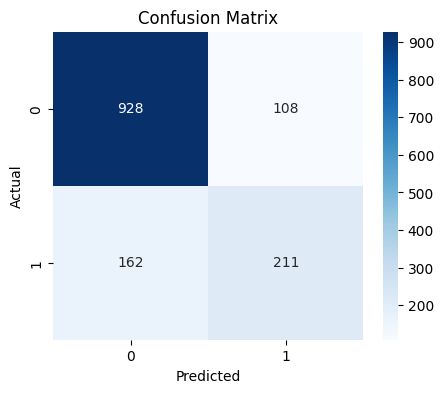

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()



In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_pred))


              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1036
           1       0.66      0.57      0.61       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



Difference between Actual and Predicted Values

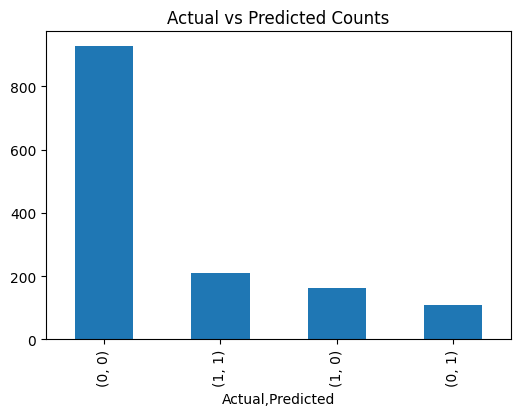

In [40]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_test_pred
})

comparison_df.value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Actual vs Predicted Counts")
plt.show()


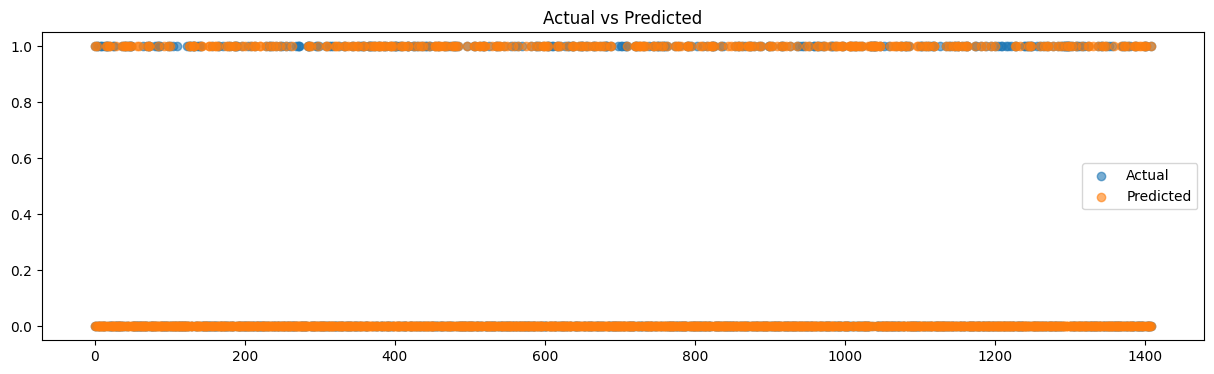

In [45]:
plt.figure(figsize=(15,4))
plt.scatter(range(len(y_test)), y_test, label='Actual', alpha=0.6)
plt.scatter(range(len(y_test_pred)), y_test_pred, label='Predicted', alpha=0.6)
plt.legend()
plt.title("Actual vs Predicted")
plt.show()


ROC

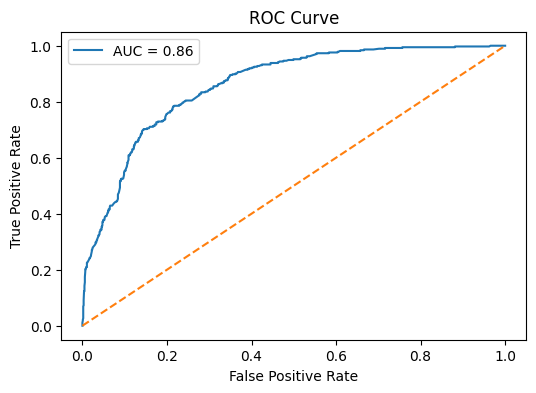

In [47]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
